In [1]:
# Data Visualization Capstone Project
# Applying advanced visualization techniques to Tesla stock dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, DatetimeTickFormatter
from bokeh.layouts import gridplot

output_notebook()

# Load the dataset
data = pd.read_csv('./TSLA.csv')

# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Sort data by Date
data = data.sort_values('Date')



Loading BokehJS ...

In [2]:
# Adding calculated columns
# 1. Daily Price Change
data['Daily_Change'] = data['High'] - data['Low']

# 2. Daily Return (percentage change in Close price)
data['Daily_Return'] = data['Close'].pct_change() * 100

# 3. Monthly Average Close Price
data['Month'] = data['Date'].dt.to_period('M')
monthly_avg = data.groupby('Month').mean().reset_index()
monthly_avg['Month'] = monthly_avg['Month'].dt.to_timestamp()



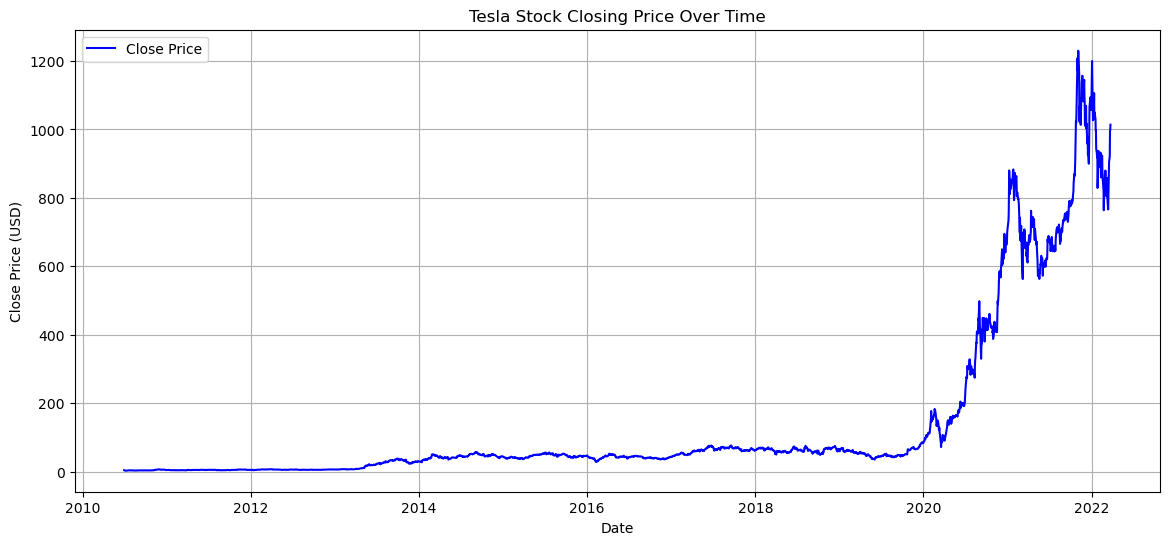

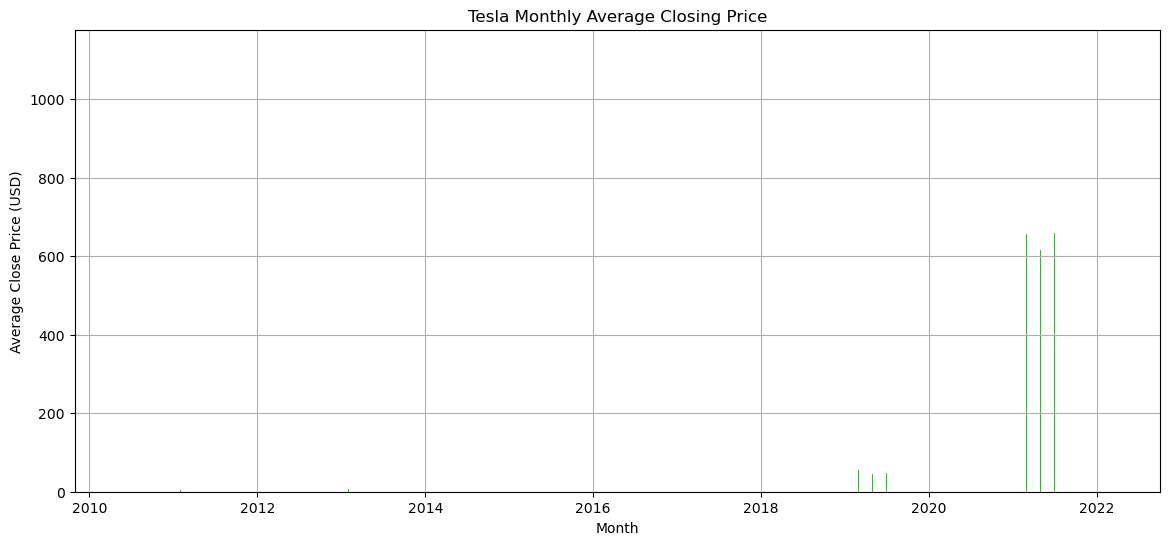

In [8]:
# Static Visualizations
# Line Chart of Closing Price
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')
plt.title('Tesla Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid()
plt.show()

# Bar Chart of Monthly Average Close Price
plt.figure(figsize=(14, 6))
plt.bar(monthly_avg['Month'], monthly_avg['Close'], color='green', alpha=0.7)
plt.title('Tesla Monthly Average Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Close Price (USD)')
plt.grid()
plt.show()

# Interactive Visualizations with Bokeh
source = ColumnDataSource(data)

# Interactive Line Chart
line_chart = figure(x_axis_type='datetime', title='Tesla Closing Price Over Time', width=900, height=400)
line_chart.line('Date', 'Close', source=source, line_width=2, color='blue', legend_label='Close Price')
line_chart.add_tools(HoverTool(tooltips=[('Date', '@Date{%F}'), ('Close', '@Close')], formatters={'@Date': 'datetime'}))
line_chart.xaxis.formatter = DatetimeTickFormatter(days='%b %d, %Y', months='%b %Y', years='%Y')
line_chart.xaxis.axis_label = 'Date'
line_chart.yaxis.axis_label = 'Close Price (USD)'

# Interactive Heatmap (Volume vs. Daily Change)
heatmap = figure(
    x_axis_label='Volume', 
    y_axis_label='Daily Change (USD)', 
    title='Volume vs. Daily Price Change', 
    width=900, 
    height=400
)
heatmap.circle('Volume', 'Daily_Change', size=5, source=source, color='navy', alpha=0.5)
heatmap.add_tools(HoverTool(tooltips=[('Volume', '@Volume'), ('Daily Change', '@Daily_Change')]))
# Dashboard with Grid Layout
layout = gridplot([[line_chart], [heatmap]])
show(layout)

# Summary:
# This project applied advanced visualization techniques:
# - Static visualizations: Line and bar charts for trends and averages.
# - Interactive visualizations: Line chart with hover details and scatter heatmap using Bokeh.
# These visualizations provide insights into Tesla's stock trends, relationships, and key metrics.
